# Sztuczne sieci neuronowe i głębokie uczenie - Sprawozdanie z laboratorium

## Temat:

Sieci generatywne GAN

### Cel ćwiczenia:

Celem ćwiczenia jest poznanie architektury Generative Adversarial Network, zaimplementowanie generatora i dyskryminatora w PyTorch, przeprowadzenie treningu GAN na zbiorze MNIST oraz analiza jakości generowanych cyfr, przebiegu funkcji strat, przestrzeni latentnej, problemu mode collapse i różnic między MLP-GAN a DCGAN.

### Wykorzystane narzędzia:

- Python 3.x
- Jupyter Notebook / JupyterLab
- PyTorch
- torchvision
- NumPy
- pandas
- matplotlib
- Zbiór danych MNIST


## Polecenia do uruchomienia

Notebook jest przygotowany tak, aby uruchamiać go komórka po komórce. Jeśli środowisko nie ma wymaganych bibliotek, zainstaluj je przed startem.

```bash
python -m pip install torch torchvision matplotlib numpy pandas notebook
jupyter notebook report.ipynb
```

Alternatywnie możesz użyć JupyterLab:

```bash
jupyter lab report.ipynb
```


## Przygotowanie środowiska

Poniższa komórka importuje biblioteki, ustawia ziarna losowości, wybiera urządzenie obliczeniowe i przygotowuje zbiór MNIST z normalizacją obrazów do zakresu `[-1, 1]`, zgodnego z wyjściem `Tanh` w generatorze.


In [2]:
%pip install torchvision


  Using cached torchvision-0.27.0-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (5.5 kB)
Using cached torchvision-0.27.0-cp313-cp313-manylinux_2_28_x86_64.whl (7.6 MB)
Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import random
from dataclasses import dataclass

os.environ.setdefault('MPLCONFIGDIR', './.matplotlib-cache')
os.makedirs(os.environ['MPLCONFIGDIR'], exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Działające źródło online dla MNIST.
if hasattr(torchvision.datasets.MNIST, 'mirrors'):
    torchvision.datasets.MNIST.mirrors = ['https://ossci-datasets.s3.amazonaws.com/mnist/']

if hasattr(torchvision.datasets.MNIST, 'urls'):
    torchvision.datasets.MNIST.urls = [
        'https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz',
        'https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz',
        'https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz',
        'https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz',
    ]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform,
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    # num_workers=0 jest stabilniejsze w Jupyterze i w środowiskach z ograniczonym multiprocessing.
    num_workers=0,
    pin_memory=False,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Urządzenie: {device}')
print(f'PyTorch: {torch.__version__}')
print(f'torchvision: {torchvision.__version__}')


Urządzenie: cpu
PyTorch: 2.12.0+cu130
torchvision: 0.27.0+cu130


/home/patryk/anaconda3/lib/python3.13/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## Funkcje pomocnicze

Funkcje służą do liczenia parametrów, wizualizacji obrazów generowanych w zakresie `[-1, 1]`, rysowania strat oraz przygotowywania porównań wyników.


In [19]:
def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters())


def show_images(images, nrow=8, title=None, figsize=(7, 7)):
    grid = make_grid(
        images.detach().cpu(),
        nrow=nrow,
        normalize=True,
        value_range=(-1, 1),
        padding=2,
    )
    plt.figure(figsize=figsize)
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


def plot_losses(d_losses, g_losses, title='Przebieg funkcji strat'):
    plt.figure(figsize=(9, 5))
    plt.plot(d_losses, label='L_D')
    plt.plot(g_losses, label='L_G')
    plt.xlabel('Epoka')
    plt.ylabel('Strata')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def generated_grid_mlp(generator, sample_count=64, latent_dim=100, nrow=8, title=None):
    generator.eval()
    with torch.no_grad():
        noise = torch.randn(sample_count, latent_dim, device=device)
        fake_images = generator(noise).view(sample_count, 1, 28, 28)
    show_images(fake_images, nrow=nrow, title=title)
    return fake_images


def generated_grid_dcgan(generator, sample_count=64, latent_dim=100, nrow=8, title=None):
    generator.eval()
    with torch.no_grad():
        noise = torch.randn(sample_count, latent_dim, 1, 1, device=device)
        fake_images = generator(noise)
    show_images(fake_images, nrow=nrow, title=title)
    return fake_images


## Zadanie 1 — Generator i Dyskryminator MLP

Zaimplementowano dwie sieci typu MLP. Generator przekształca wektor latentny `z` o rozmiarze 100 do spłaszczonego obrazu MNIST o rozmiarze 784. Dyskryminator klasyfikuje spłaszczony obraz jako prawdziwy albo wygenerowany.


In [6]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, img_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, img_dim),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, img_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(img_dim, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, img):
        return self.net(img)


In [7]:
latent_dim = 100
G_test = Generator(latent_dim).to(device)
D_test = Discriminator().to(device)

z = torch.randn(16, latent_dim, device=device)
generated = G_test(z)
discriminator_output = D_test(generated)

print('G(z):', tuple(generated.shape))
print('D(G(z)):', tuple(discriminator_output.shape))
print('Parametry Generatora:', count_parameters(G_test))
print('Parametry Dyskryminatora:', count_parameters(D_test))

assert generated.shape == (16, 784)
assert discriminator_output.shape == (16, 1)


G(z): (16, 784)
D(G(z)): (16, 1)
Parametry Generatora: 1486352
Parametry Dyskryminatora: 1460225


### Odpowiedź do zadania 1

Generator ma **1 486 352** parametry, a Dyskryminator ma **1 460 225** parametrów. W Generatorze najwięcej parametrów ma ostatnia warstwa `Linear(1024, 784)`, czyli 803 600 parametrów. W Dyskryminatorze najwięcej parametrów ma pierwsza warstwa `Linear(784, 1024)`, czyli 803 840 parametrów.


## Zadanie 2 — Trening MLP-GAN

Pętla treningowa wykonuje naprzemiennie krok Dyskryminatora i Generatora. Przy aktualizacji Dyskryminatora próbki z Generatora są odłączane przez `.detach()`, aby gradient nie aktualizował Generatora. Przy aktualizacji Generatora wagi Dyskryminatora są tymczasowo zamrażane.


In [8]:
@dataclass
class GanResult:
    generator: nn.Module
    discriminator: nn.Module
    d_losses: list
    g_losses: list
    snapshots: dict


def set_requires_grad(model, requires_grad):
    for parameter in model.parameters():
        parameter.requires_grad_(requires_grad)


def train_mlp_gan(lr=2e-4, epochs=50, latent_dim=100, preview_epochs=(10, 20, 30, 40, 50)):
    generator = Generator(latent_dim).to(device)
    discriminator = Discriminator().to(device)
    criterion = nn.BCELoss()
    opt_G = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

    fixed_noise = torch.randn(64, latent_dim, device=device)
    d_losses = []
    g_losses = []
    snapshots = {}

    for epoch in range(1, epochs + 1):
        generator.train()
        discriminator.train()
        epoch_d_loss = 0.0
        epoch_g_loss = 0.0
        batch_count = 0

        for real_imgs, _ in dataloader:
            real_imgs = real_imgs.view(-1, 784).to(device)
            batch_size = real_imgs.size(0)
            real_labels = torch.ones(batch_size, 1, device=device)
            fake_labels = torch.zeros(batch_size, 1, device=device)

            # Krok 1: trening Dyskryminatora.
            set_requires_grad(discriminator, True)
            opt_D.zero_grad(set_to_none=True)

            real_loss = criterion(discriminator(real_imgs), real_labels)
            noise = torch.randn(batch_size, latent_dim, device=device)
            fake_imgs = generator(noise)
            fake_loss = criterion(discriminator(fake_imgs.detach()), fake_labels)
            d_loss = (real_loss + fake_loss) / 2

            d_loss.backward()
            opt_D.step()

            # Krok 2: trening Generatora.
            set_requires_grad(discriminator, False)
            opt_G.zero_grad(set_to_none=True)

            noise = torch.randn(batch_size, latent_dim, device=device)
            fake_imgs = generator(noise)
            g_loss = criterion(discriminator(fake_imgs), real_labels)

            g_loss.backward()
            opt_G.step()
            set_requires_grad(discriminator, True)

            epoch_d_loss += d_loss.item()
            epoch_g_loss += g_loss.item()
            batch_count += 1

        avg_d_loss = epoch_d_loss / batch_count
        avg_g_loss = epoch_g_loss / batch_count
        d_losses.append(avg_d_loss)
        g_losses.append(avg_g_loss)

        print(f'Epoka {epoch:02d}/{epochs}: L_D={avg_d_loss:.4f}, L_G={avg_g_loss:.4f}')

        if epoch in preview_epochs:
            generator.eval()
            with torch.no_grad():
                preview = generator(fixed_noise).view(64, 1, 28, 28).detach().cpu()
            snapshots[epoch] = preview
            show_images(preview, nrow=8, title=f'MLP-GAN, lr={lr}, epoka {epoch}')

    return GanResult(generator, discriminator, d_losses, g_losses, snapshots)


Epoka 01/50: L_D=0.3688, L_G=2.4777
Epoka 02/50: L_D=0.2710, L_G=2.9772
Epoka 03/50: L_D=0.2612, L_G=2.5987
Epoka 04/50: L_D=0.3062, L_G=2.2644
Epoka 05/50: L_D=0.3625, L_G=1.9278
Epoka 06/50: L_D=0.4413, L_G=1.5751
Epoka 07/50: L_D=0.4683, L_G=1.4788
Epoka 08/50: L_D=0.4923, L_G=1.3694
Epoka 09/50: L_D=0.5059, L_G=1.3169
Epoka 10/50: L_D=0.5184, L_G=1.2828


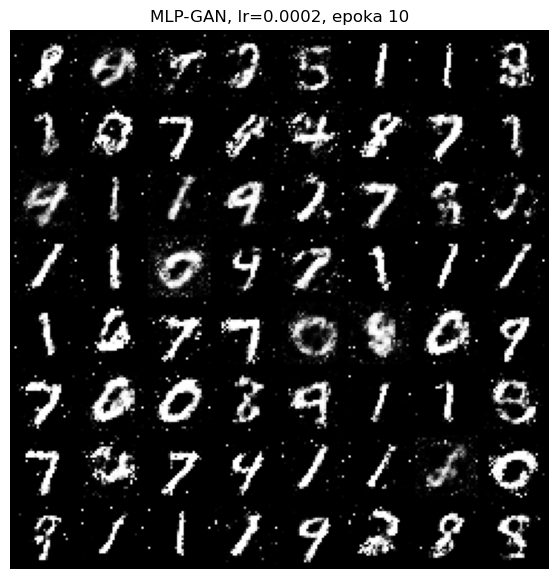

Epoka 11/50: L_D=0.5232, L_G=1.2587
Epoka 12/50: L_D=0.5263, L_G=1.2495
Epoka 13/50: L_D=0.5327, L_G=1.2273
Epoka 14/50: L_D=0.5422, L_G=1.1929
Epoka 15/50: L_D=0.5526, L_G=1.1621
Epoka 16/50: L_D=0.5600, L_G=1.1305
Epoka 17/50: L_D=0.5652, L_G=1.1162
Epoka 18/50: L_D=0.5666, L_G=1.1096
Epoka 19/50: L_D=0.5734, L_G=1.0937
Epoka 20/50: L_D=0.5758, L_G=1.0854


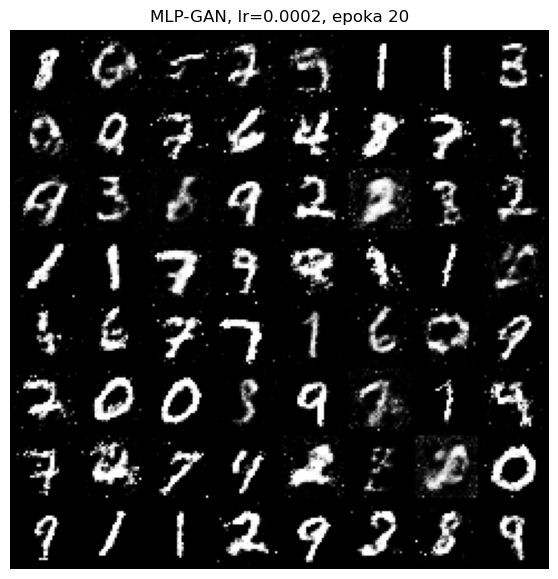

Epoka 21/50: L_D=0.5840, L_G=1.0638
Epoka 22/50: L_D=0.5864, L_G=1.0492
Epoka 23/50: L_D=0.5862, L_G=1.0516
Epoka 24/50: L_D=0.5859, L_G=1.0545
Epoka 25/50: L_D=0.5889, L_G=1.0504
Epoka 26/50: L_D=0.5905, L_G=1.0357
Epoka 27/50: L_D=0.5922, L_G=1.0331
Epoka 28/50: L_D=0.5919, L_G=1.0376
Epoka 29/50: L_D=0.5949, L_G=1.0271
Epoka 30/50: L_D=0.5938, L_G=1.0319


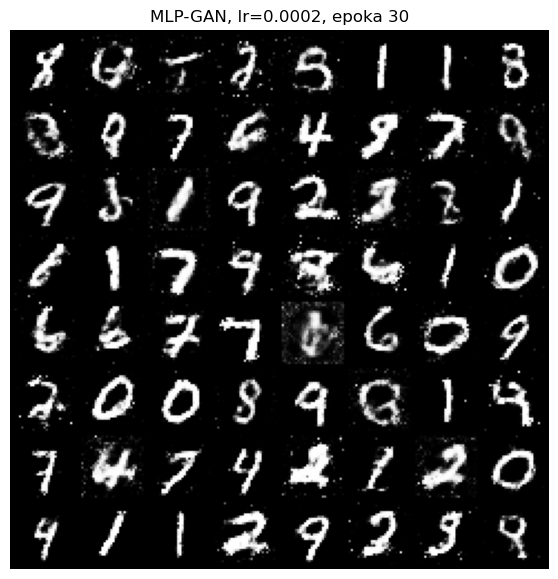

Epoka 31/50: L_D=0.5936, L_G=1.0235
Epoka 32/50: L_D=0.5943, L_G=1.0257
Epoka 33/50: L_D=0.5951, L_G=1.0262
Epoka 34/50: L_D=0.5927, L_G=1.0287
Epoka 35/50: L_D=0.5942, L_G=1.0231
Epoka 36/50: L_D=0.5980, L_G=1.0122
Epoka 37/50: L_D=0.5941, L_G=1.0250
Epoka 38/50: L_D=0.5960, L_G=1.0178
Epoka 39/50: L_D=0.5974, L_G=1.0148
Epoka 40/50: L_D=0.5979, L_G=1.0141


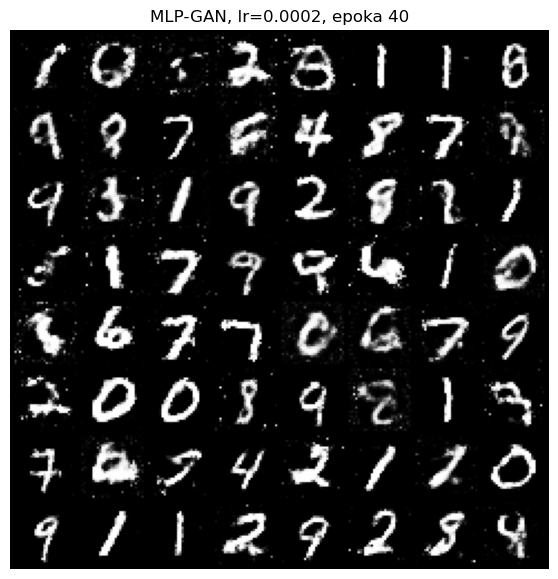

Epoka 41/50: L_D=0.5976, L_G=1.0136
Epoka 42/50: L_D=0.5966, L_G=1.0142
Epoka 43/50: L_D=0.5982, L_G=1.0086
Epoka 44/50: L_D=0.5970, L_G=1.0150
Epoka 45/50: L_D=0.5992, L_G=1.0085
Epoka 46/50: L_D=0.6003, L_G=1.0004
Epoka 47/50: L_D=0.5983, L_G=1.0085
Epoka 48/50: L_D=0.5992, L_G=1.0036
Epoka 49/50: L_D=0.5986, L_G=1.0036
Epoka 50/50: L_D=0.5994, L_G=1.0058


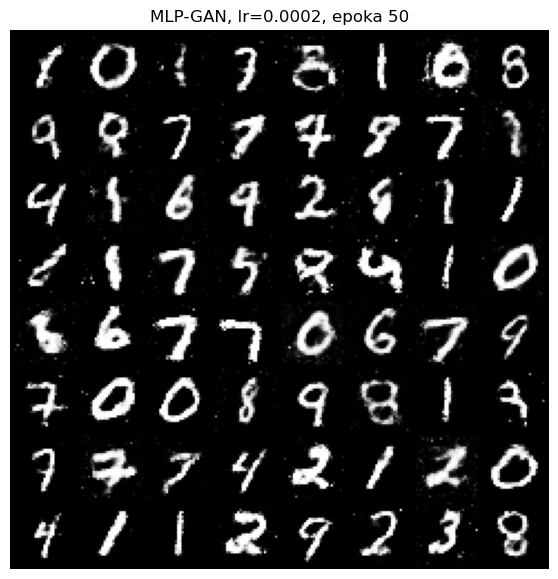

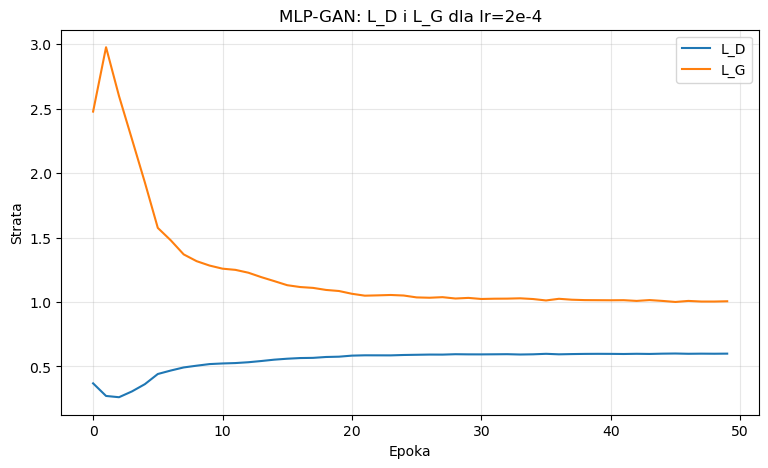

In [9]:
# Uruchom tę komórkę, aby wykonać trening z zadania 2.
mlp_result = train_mlp_gan(lr=2e-4, epochs=50)
plot_losses(mlp_result.d_losses, mlp_result.g_losses, title='MLP-GAN: L_D i L_G dla lr=2e-4')


### Obserwacje do zadania 2

Na pierwszej zapisanej siatce, po 10 epokach, większość cyfr jest już rozpoznawalna, chociaż obrazy zawierają jeszcze liczne jasne artefakty i część kształtów jest niejednoznaczna. W kolejnych epokach kontury stają się wyraźniejsze, ale drobny szum pozostaje widoczny także po 50 epokach.

- Pierwsze rozpoznawalne cyfry pojawiły się około epoki: **10**.
- Zachowanie `L_D`: **początkowo spadła z 0,3688 do 0,2612, następnie stopniowo wzrosła i ustabilizowała się w pobliżu 0,60**.
- Zachowanie `L_G`: **na początku wzrosła do 2,9772, a później systematycznie malała i po 50 epokach osiągnęła 1,0058**.

Typowo w GAN straty nie muszą monotonicznie spadać. Oscylacje są naturalne, bo Generator i Dyskryminator uczą się w układzie antagonistycznym.


## Zadanie 3 — Eksploracja przestrzeni latentnej

W tej części używany jest Generator wytrenowany w zadaniu 2. Najpierw generowane jest 100 niezależnych próbek, a następnie wykonywana jest interpolacja liniowa między dwoma punktami przestrzeni latentnej.


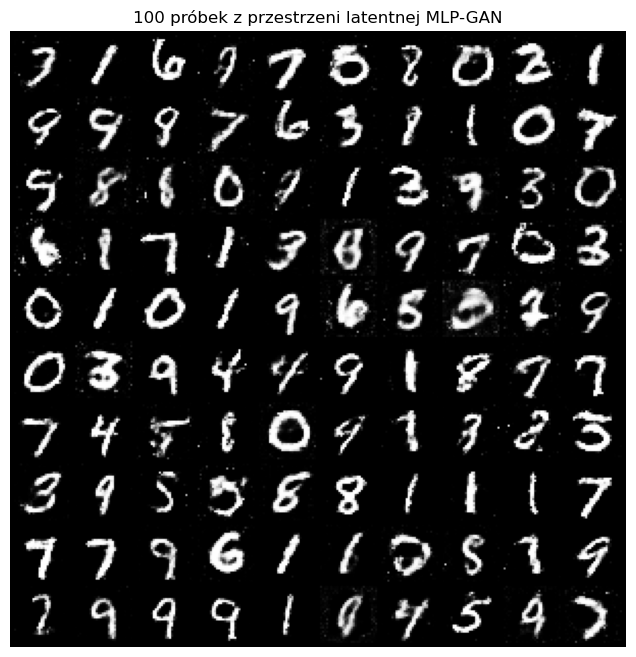

In [10]:
# 100 próbek jako siatka 10x10.
mlp_result.generator.eval()
with torch.no_grad():
    z = torch.randn(100, latent_dim, device=device)
    samples_100 = mlp_result.generator(z).view(100, 1, 28, 28)
show_images(samples_100, nrow=10, title='100 próbek z przestrzeni latentnej MLP-GAN', figsize=(8, 8))


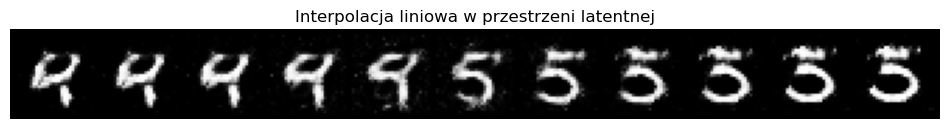

In [11]:
# Interpolacja liniowa między dwoma punktami latentnymi.
mlp_result.generator.eval()
with torch.no_grad():
    z_1 = torch.randn(1, latent_dim, device=device)
    z_2 = torch.randn(1, latent_dim, device=device)
    interpolation_points = torch.linspace(0, 1, steps=11, device=device).view(-1, 1)
    z_interp = (1 - interpolation_points) * z_1 + interpolation_points * z_2
    interpolated_images = mlp_result.generator(z_interp).view(11, 1, 28, 28)
show_images(interpolated_images, nrow=11, title='Interpolacja liniowa w przestrzeni latentnej', figsize=(12, 2))


### Obserwacje do zadania 3

Siatka 100 próbek zawiera zróżnicowane i w większości rozpoznawalne cyfry. Interpolacja pokazuje stopniową zmianę obrazu od kształtu zbliżonego do cyfry `4` do cyfry `5`.

- Przejścia między cyframi są: **płynne; kolejne obrazy zmieniają kształt stopniowo**.
- Widoczne artefakty lub nagłe zmiany: **widoczne są niewielkie rozmycia i szum, ale nie występują gwałtowne skoki między kolejnymi punktami**.
- Wniosek o przestrzeni latentnej: **Generator nauczył się ciągłej i względnie uporządkowanej reprezentacji, w której sąsiednie punkty odpowiadają podobnym obrazom**.

Jeśli interpolacja jest płynna, oznacza to, że Generator nauczył się względnie uporządkowanej reprezentacji, w której bliskie punkty latentne dają wizualnie podobne obrazy.


## Zadanie 4 — Analiza problemu mode collapse

Eksperyment powtarza trening MLP-GAN z dziesięciokrotnie większym learning rate `lr=2e-3`. Taki parametr często destabilizuje trening i może prowadzić do generowania mało zróżnicowanych próbek.


Epoka 01/50: L_D=0.4930, L_G=4.2347
Epoka 02/50: L_D=44.2150, L_G=0.8869
Epoka 03/50: L_D=50.0000, L_G=0.0000
Epoka 04/50: L_D=50.0000, L_G=0.0000
Epoka 05/50: L_D=50.0000, L_G=0.0000
Epoka 06/50: L_D=50.0000, L_G=0.0000
Epoka 07/50: L_D=50.0000, L_G=0.0000
Epoka 08/50: L_D=50.0000, L_G=0.0000
Epoka 09/50: L_D=50.0000, L_G=0.0000
Epoka 10/50: L_D=50.0000, L_G=0.0000


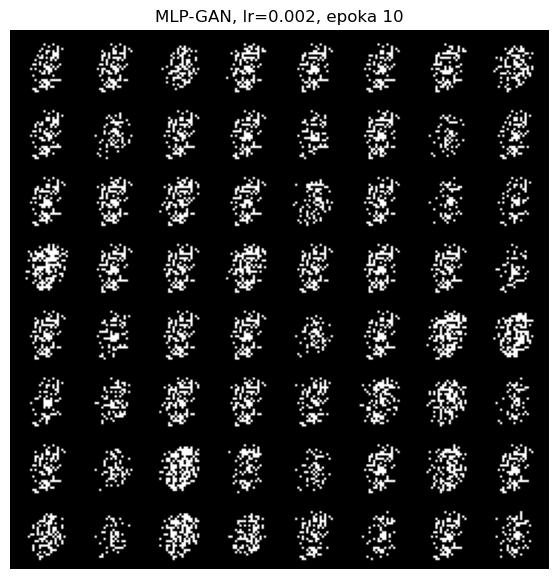

Epoka 11/50: L_D=50.0000, L_G=0.0000
Epoka 12/50: L_D=50.0000, L_G=0.0000
Epoka 13/50: L_D=50.0000, L_G=0.0000
Epoka 14/50: L_D=50.0000, L_G=0.0000
Epoka 15/50: L_D=50.0000, L_G=0.0000
Epoka 16/50: L_D=50.0000, L_G=0.0000
Epoka 17/50: L_D=50.0000, L_G=0.0000
Epoka 18/50: L_D=50.0000, L_G=0.0000
Epoka 19/50: L_D=50.0000, L_G=0.0000
Epoka 20/50: L_D=50.0000, L_G=0.0000


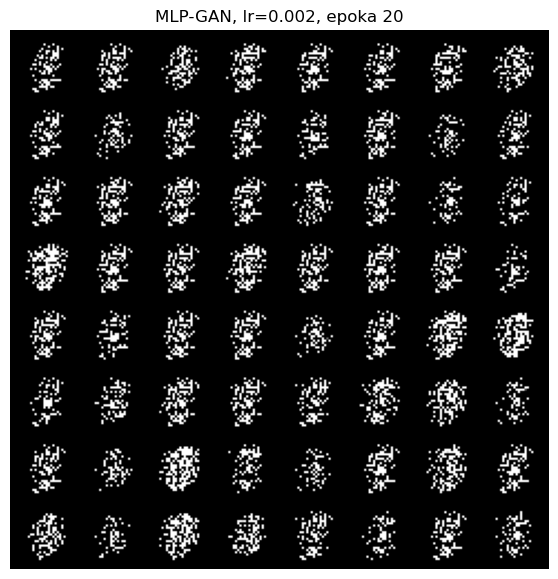

Epoka 21/50: L_D=50.0000, L_G=0.0000
Epoka 22/50: L_D=50.0000, L_G=0.0000
Epoka 23/50: L_D=50.0000, L_G=0.0000
Epoka 24/50: L_D=50.0000, L_G=0.0000
Epoka 25/50: L_D=50.0000, L_G=0.0000
Epoka 26/50: L_D=50.0000, L_G=0.0000
Epoka 27/50: L_D=50.0000, L_G=0.0000
Epoka 28/50: L_D=50.0000, L_G=0.0000
Epoka 29/50: L_D=50.0000, L_G=0.0000
Epoka 30/50: L_D=50.0000, L_G=0.0000


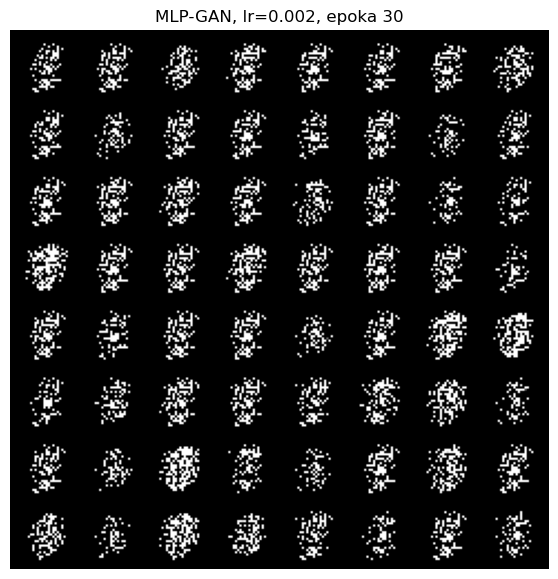

Epoka 31/50: L_D=50.0000, L_G=0.0000
Epoka 32/50: L_D=50.0000, L_G=0.0000
Epoka 33/50: L_D=50.0000, L_G=0.0000
Epoka 34/50: L_D=50.0000, L_G=0.0000
Epoka 35/50: L_D=50.0000, L_G=0.0000
Epoka 36/50: L_D=50.0000, L_G=0.0000
Epoka 37/50: L_D=50.0000, L_G=0.0000
Epoka 38/50: L_D=50.0000, L_G=0.0000
Epoka 39/50: L_D=50.0000, L_G=0.0000
Epoka 40/50: L_D=50.0000, L_G=0.0000


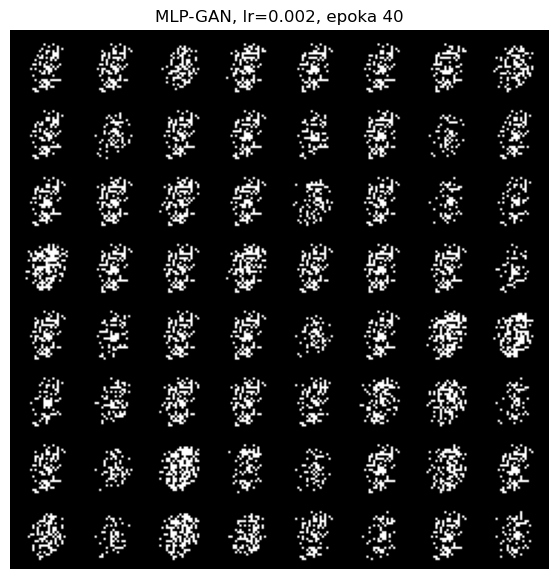

Epoka 41/50: L_D=50.0000, L_G=0.0000
Epoka 42/50: L_D=50.0000, L_G=0.0000
Epoka 43/50: L_D=50.0000, L_G=0.0000
Epoka 44/50: L_D=50.0000, L_G=0.0000
Epoka 45/50: L_D=50.0000, L_G=0.0000
Epoka 46/50: L_D=50.0000, L_G=0.0000
Epoka 47/50: L_D=50.0000, L_G=0.0000
Epoka 48/50: L_D=50.0000, L_G=0.0000
Epoka 49/50: L_D=50.0000, L_G=0.0000
Epoka 50/50: L_D=50.0000, L_G=0.0000


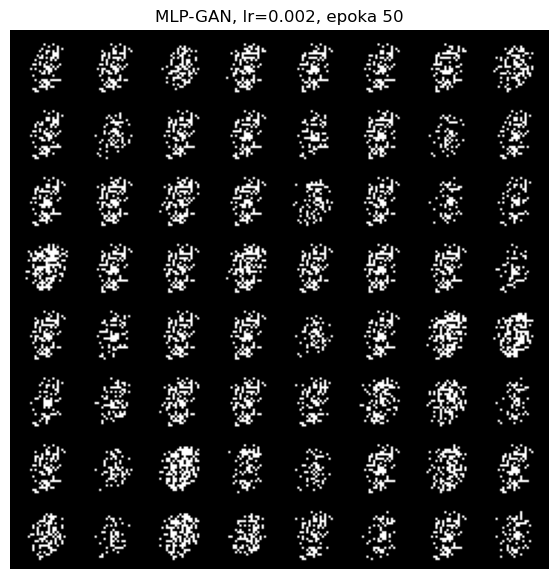

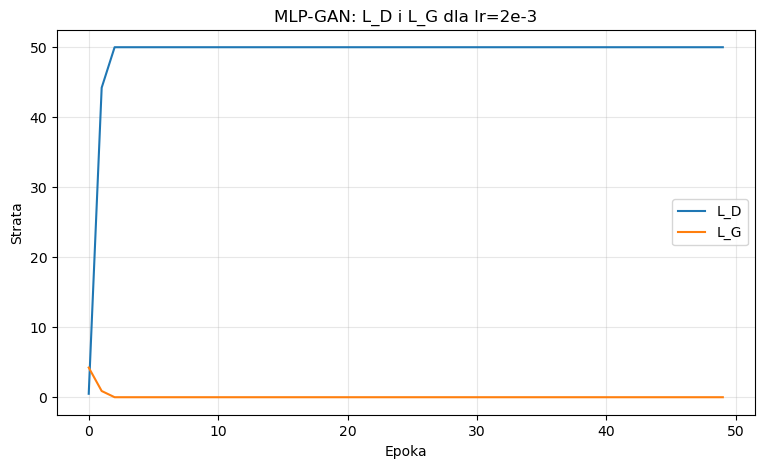

In [12]:
# Uruchom tę komórkę, aby wykonać trening porównawczy z większym learning rate.
mlp_high_lr_result = train_mlp_gan(lr=2e-3, epochs=50)
plot_losses(
    mlp_high_lr_result.d_losses,
    mlp_high_lr_result.g_losses,
    title='MLP-GAN: L_D i L_G dla lr=2e-3',
)


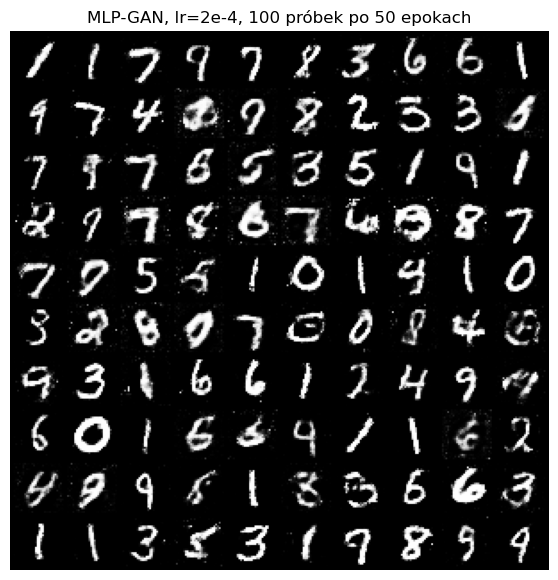

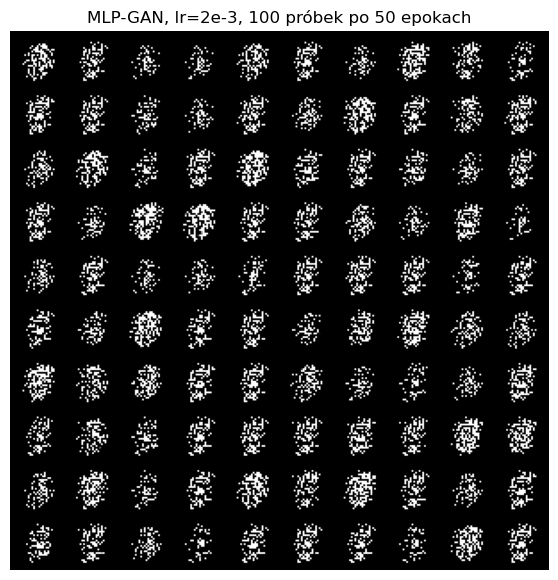

In [13]:
# Porównanie siatek 100 próbek po 50 epokach.
mlp_100_lr_2e4 = generated_grid_mlp(
    mlp_result.generator,
    sample_count=100,
    latent_dim=latent_dim,
    nrow=10,
    title='MLP-GAN, lr=2e-4, 100 próbek po 50 epokach',
)
mlp_100_lr_2e3 = generated_grid_mlp(
    mlp_high_lr_result.generator,
    sample_count=100,
    latent_dim=latent_dim,
    nrow=10,
    title='MLP-GAN, lr=2e-3, 100 próbek po 50 epokach',
)


In [14]:
# Po obejrzeniu siatek wpisz ręcznie liczbę unikalnych cyfr widocznych w 100 próbkach.
# Przykład: jeśli widzisz głównie 1, 7 i 9, wpisz 3.
unique_digits_lr_2e4 = None  # TODO: wpisz liczbę po obejrzeniu siatki
unique_digits_lr_2e3 = None  # TODO: wpisz liczbę po obejrzeniu siatki

mode_collapse_summary = pd.DataFrame([
    {
        'lr': 2e-4,
        'liczba_unikalnych_cyfr': unique_digits_lr_2e4,
        'srednia_L_D_po_50_epokach': mlp_result.d_losses[-1],
        'srednia_L_G_po_50_epokach': mlp_result.g_losses[-1],
    },
    {
        'lr': 2e-3,
        'liczba_unikalnych_cyfr': unique_digits_lr_2e3,
        'srednia_L_D_po_50_epokach': mlp_high_lr_result.d_losses[-1],
        'srednia_L_G_po_50_epokach': mlp_high_lr_result.g_losses[-1],
    },
])
mode_collapse_summary


,lr,liczba_unikalnych_cyfr,srednia_L_D_po_50_epokach,srednia_L_G_po_50_epokach
0,0.0002,None,0.599384,1.005818
1,0.0020,None,50.000000,0.000000


### Odpowiedź do zadania 4

Mode collapse to zjawisko, w którym Generator produkuje ograniczony zestaw bardzo podobnych próbek, zamiast odwzorowywać pełną różnorodność rozkładu danych. W przypadku MNIST objawem jest np. generowanie wielu podobnych cyfr i brak części klas cyfr w siatce wygenerowanych obrazów.

W siatce dla `lr=2e-4` występują przykłady wszystkich dziesięciu klas cyfr, choć część próbek jest niejednoznaczna. Dla `lr=2e-3` nie da się rozpoznać żadnej cyfry: Generator produkuje wyłącznie zaszumione wzory. Przebieg strat potwierdza załamanie treningu już od 3. epoki (`L_D=50,0000`, `L_G=0,0000`).

- Objawy dla `lr=2e-4`: **duża różnorodność próbek i brak wyraźnego mode collapse; widoczne są wszystkie klasy cyfr**.
- Objawy dla `lr=2e-3`: **całkowita utrata zdolności generowania cyfr i degeneracja wyników do szumu**.
- Który wariant wykazuje silniejszy mode collapse: **wariant `lr=2e-3` wykazuje znacznie silniejszą degenerację, jednak jest to przede wszystkim niestabilność i załamanie treningu, a nie klasyczny mode collapse do kilku rozpoznawalnych cyfr**.

Techniki ograniczające mode collapse: **WGAN/WGAN-GP**, czyli zmiana funkcji celu i stabilizacja gradientów, oraz **minibatch discrimination**, czyli dostarczenie Dyskryminatorowi informacji o podobieństwie próbek w obrębie batcha.


## Zadanie 5 — Porównanie MLP-GAN z DCGAN

DCGAN pracuje bezpośrednio na strukturze obrazów `1 x 28 x 28`. Generator wykorzystuje `ConvTranspose2d`, a Dyskryminator `Conv2d`, dzięki czemu model korzysta z lokalnych zależności przestrzennych obrazu.


In [15]:
class DCGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 128, kernel_size=7, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)


class DCDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid(),
        )

    def forward(self, img):
        return self.net(img)


In [16]:
def train_dcgan(lr=2e-4, epochs=50, latent_dim=100, preview_epochs=(10, 30, 50)):
    generator = DCGenerator(latent_dim).to(device)
    discriminator = DCDiscriminator().to(device)
    criterion = nn.BCELoss()
    opt_G = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

    fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)
    d_losses = []
    g_losses = []
    snapshots = {}

    for epoch in range(1, epochs + 1):
        generator.train()
        discriminator.train()
        epoch_d_loss = 0.0
        epoch_g_loss = 0.0
        batch_count = 0

        for real_imgs, _ in dataloader:
            real_imgs = real_imgs.to(device)
            batch_size = real_imgs.size(0)
            real_labels = torch.ones(batch_size, 1, device=device)
            fake_labels = torch.zeros(batch_size, 1, device=device)

            # Krok 1: trening Dyskryminatora.
            set_requires_grad(discriminator, True)
            opt_D.zero_grad(set_to_none=True)

            real_loss = criterion(discriminator(real_imgs), real_labels)
            noise = torch.randn(batch_size, latent_dim, 1, 1, device=device)
            fake_imgs = generator(noise)
            fake_loss = criterion(discriminator(fake_imgs.detach()), fake_labels)
            d_loss = (real_loss + fake_loss) / 2

            d_loss.backward()
            opt_D.step()

            # Krok 2: trening Generatora.
            set_requires_grad(discriminator, False)
            opt_G.zero_grad(set_to_none=True)

            noise = torch.randn(batch_size, latent_dim, 1, 1, device=device)
            fake_imgs = generator(noise)
            g_loss = criterion(discriminator(fake_imgs), real_labels)

            g_loss.backward()
            opt_G.step()
            set_requires_grad(discriminator, True)

            epoch_d_loss += d_loss.item()
            epoch_g_loss += g_loss.item()
            batch_count += 1

        avg_d_loss = epoch_d_loss / batch_count
        avg_g_loss = epoch_g_loss / batch_count
        d_losses.append(avg_d_loss)
        g_losses.append(avg_g_loss)

        print(f'Epoka {epoch:02d}/{epochs}: L_D={avg_d_loss:.4f}, L_G={avg_g_loss:.4f}')

        if epoch in preview_epochs:
            generator.eval()
            with torch.no_grad():
                preview = generator(fixed_noise).detach().cpu()
            snapshots[epoch] = preview
            show_images(preview, nrow=8, title=f'DCGAN, lr={lr}, epoka {epoch}')

    return GanResult(generator, discriminator, d_losses, g_losses, snapshots)


Epoka 01/50: L_D=0.4186, L_G=2.0868
Epoka 02/50: L_D=0.5339, L_G=1.1874
Epoka 03/50: L_D=0.5799, L_G=1.0780
Epoka 04/50: L_D=0.5964, L_G=1.0272
Epoka 05/50: L_D=0.6062, L_G=1.0051
Epoka 06/50: L_D=0.6101, L_G=0.9909
Epoka 07/50: L_D=0.6146, L_G=0.9713
Epoka 08/50: L_D=0.6176, L_G=0.9665
Epoka 09/50: L_D=0.6177, L_G=0.9661
Epoka 10/50: L_D=0.6186, L_G=0.9574


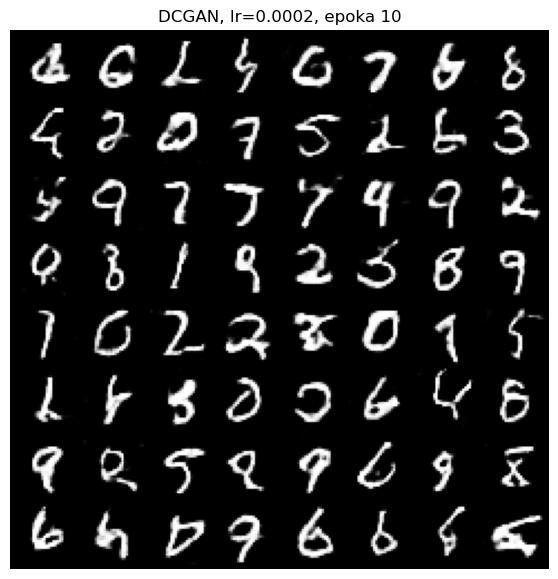

Epoka 11/50: L_D=0.6202, L_G=0.9611
Epoka 12/50: L_D=0.6204, L_G=0.9624
Epoka 13/50: L_D=0.6146, L_G=0.9540
Epoka 14/50: L_D=0.6125, L_G=0.9677
Epoka 15/50: L_D=0.6135, L_G=0.9747
Epoka 16/50: L_D=0.6106, L_G=0.9763
Epoka 17/50: L_D=0.6070, L_G=1.0007
Epoka 18/50: L_D=0.6040, L_G=0.9964
Epoka 19/50: L_D=0.6019, L_G=1.0096
Epoka 20/50: L_D=0.5970, L_G=1.0258
Epoka 21/50: L_D=0.5914, L_G=1.0448
Epoka 22/50: L_D=0.5918, L_G=1.0475
Epoka 23/50: L_D=0.5847, L_G=1.0620
Epoka 24/50: L_D=0.5825, L_G=1.0740
Epoka 25/50: L_D=0.5801, L_G=1.0817
Epoka 26/50: L_D=0.5772, L_G=1.0943
Epoka 27/50: L_D=0.5764, L_G=1.0993
Epoka 28/50: L_D=0.5704, L_G=1.1187
Epoka 29/50: L_D=0.5700, L_G=1.1272
Epoka 30/50: L_D=0.5613, L_G=1.1347


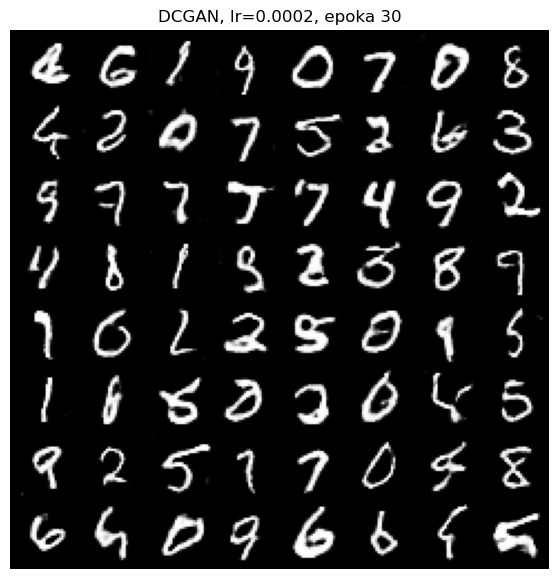

Epoka 31/50: L_D=0.5629, L_G=1.1593
Epoka 32/50: L_D=0.5578, L_G=1.1602
Epoka 33/50: L_D=0.5575, L_G=1.1771
Epoka 34/50: L_D=0.5541, L_G=1.1873
Epoka 35/50: L_D=0.5516, L_G=1.1911
Epoka 36/50: L_D=0.5496, L_G=1.1953
Epoka 37/50: L_D=0.5451, L_G=1.2081
Epoka 38/50: L_D=0.5454, L_G=1.2033
Epoka 39/50: L_D=0.5461, L_G=1.2113
Epoka 40/50: L_D=0.5404, L_G=1.2414
Epoka 41/50: L_D=0.5373, L_G=1.2332
Epoka 42/50: L_D=0.5433, L_G=1.2378
Epoka 43/50: L_D=0.5353, L_G=1.2640
Epoka 44/50: L_D=0.5382, L_G=1.2432
Epoka 45/50: L_D=0.5349, L_G=1.2535
Epoka 46/50: L_D=0.5304, L_G=1.2813
Epoka 47/50: L_D=0.5323, L_G=1.2725
Epoka 48/50: L_D=0.5338, L_G=1.2678
Epoka 49/50: L_D=0.5276, L_G=1.2696
Epoka 50/50: L_D=0.5240, L_G=1.3020


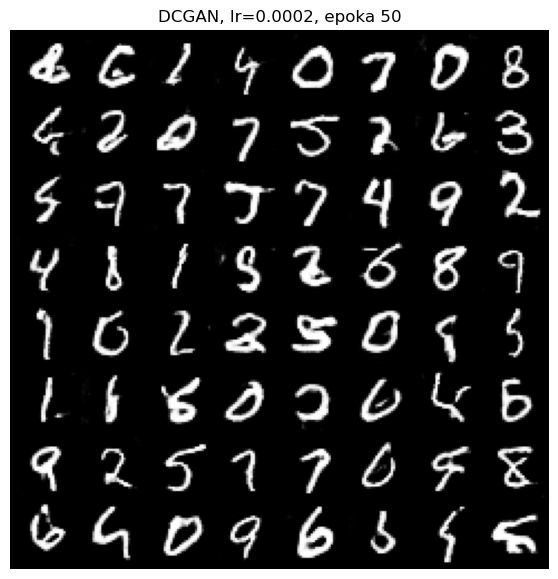

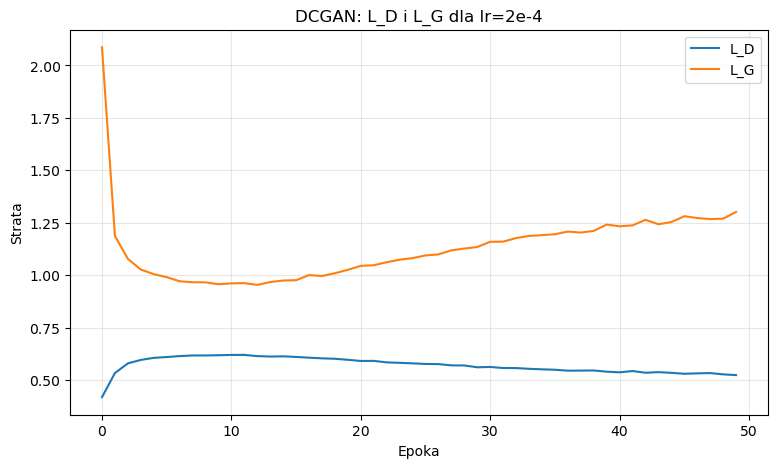

In [17]:
# Uruchom tę komórkę, aby wytrenować DCGAN.
dcgan_result = train_dcgan(lr=2e-4, epochs=50)
plot_losses(dcgan_result.d_losses, dcgan_result.g_losses, title='DCGAN: L_D i L_G dla lr=2e-4')


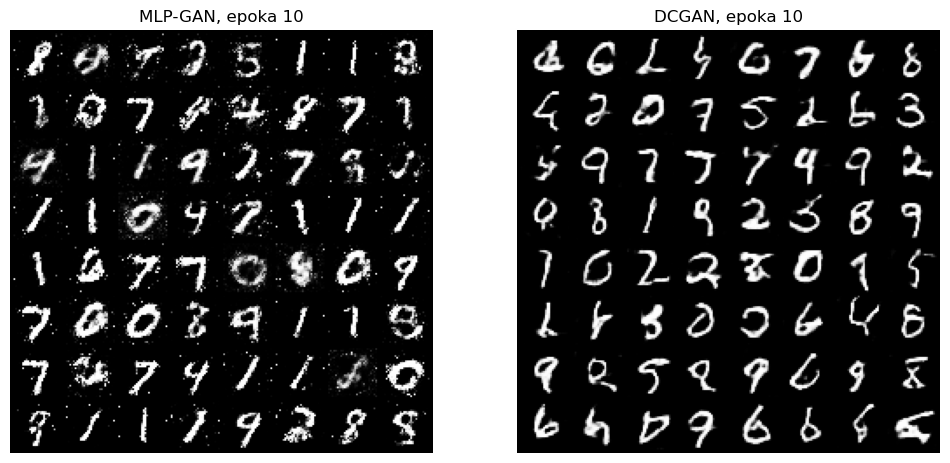

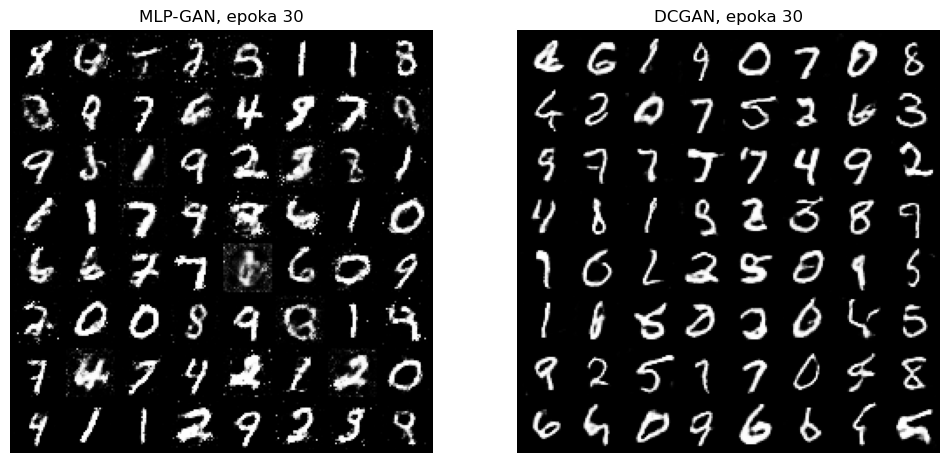

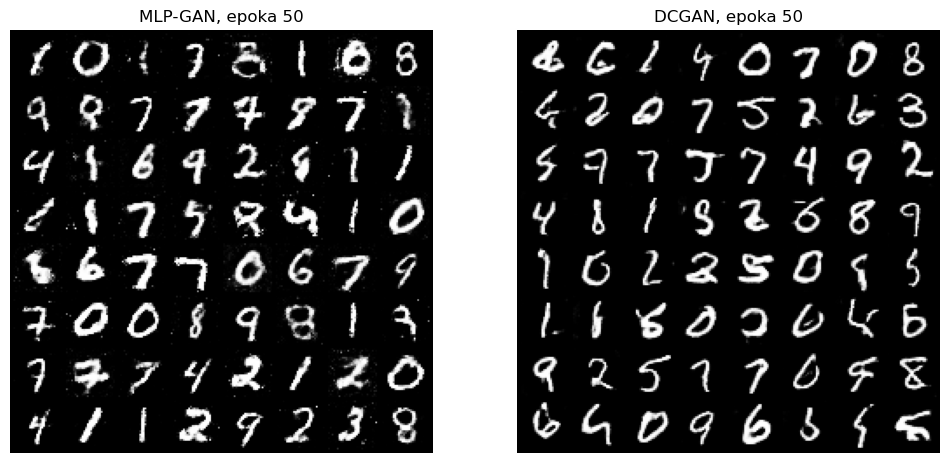

In [18]:
def compare_snapshots(mlp_result, dcgan_result, epochs=(10, 30, 50)):
    for epoch in epochs:
        mlp_grid = make_grid(
            mlp_result.snapshots[epoch],
            nrow=8,
            normalize=True,
            value_range=(-1, 1),
            padding=2,
        )
        dcgan_grid = make_grid(
            dcgan_result.snapshots[epoch],
            nrow=8,
            normalize=True,
            value_range=(-1, 1),
            padding=2,
        )

        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        axes[0].imshow(mlp_grid.permute(1, 2, 0).squeeze(), cmap='gray')
        axes[0].set_title(f'MLP-GAN, epoka {epoch}')
        axes[0].axis('off')

        axes[1].imshow(dcgan_grid.permute(1, 2, 0).squeeze(), cmap='gray')
        axes[1].set_title(f'DCGAN, epoka {epoch}')
        axes[1].axis('off')

        plt.show()


compare_snapshots(mlp_result, dcgan_result, epochs=(10, 30, 50))


### Odpowiedź do zadania 5

We wszystkich trzech punktach porównania DCGAN generuje bardziej regularne i czystsze obrazy niż MLP-GAN.

- Lepsze wyniki wygenerował model: **DCGAN**.
- Różnice po 10 epokach: **DCGAN tworzy już wyraźne cyfry o gładkich konturach, natomiast obrazy MLP-GAN zawierają dużo szumu i artefaktów**.
- Różnice po 30 epokach: **MLP-GAN poprawia czytelność cyfr, ale nadal pozostawia artefakty; wyniki DCGAN są czystsze i bardziej spójne**.
- Różnice po 50 epokach: **oba modele generują rozpoznawalne i zróżnicowane cyfry, lecz DCGAN zachowuje wyraźniejsze kontury oraz niemal pozbawione szumu tło**.

`ConvTranspose2d` jest lepszym wyborem dla danych obrazowych niż same warstwy `Linear`, ponieważ zachowuje lokalny układ przestrzenny pikseli i wykorzystuje współdzielenie wag. Dzięki temu model ma silniejsze założenie indukcyjne dopasowane do obrazów: sąsiednie piksele i lokalne wzorce, takie jak kreski cyfr, są przetwarzane wspólnie. MLP traktuje każdy piksel jako niezależną cechę po spłaszczeniu obrazu, przez co trudniej uczy się lokalnej struktury obrazu.


## Wnioski

Przeprowadzone eksperymenty potwierdziły, że GAN wymaga zachowania równowagi między uczonymi antagonistycznie Generatorem i Dyskryminatorem. Dla MLP-GAN z `lr=2e-4` pierwsza zapisana siatka po 10 epokach zawierała już rozpoznawalne cyfry, a po 50 epokach model generował zróżnicowane przykłady wszystkich klas. Straty ustabilizowały się na poziomie `L_D=0,5994` i `L_G=1,0058`, co odpowiadało stabilnemu, choć nadal lekko zaszumionemu wynikowi.

Interpolacja w przestrzeni latentnej przebiegała płynnie od kształtu zbliżonego do `4` do `5`, bez nagłych zmian obrazu. Oznacza to, że Generator nauczył się ciągłej reprezentacji, w której bliskie wektory latentne prowadzą do podobnych próbek.

Dziesięciokrotne zwiększenie learning rate do `2e-3` całkowicie zdestabilizowało trening: od 3. epoki straty utrzymywały skrajne wartości `L_D=50,0000` i `L_G=0,0000`, a Generator tworzył wyłącznie szum. Wynik ten pokazuje dużą wrażliwość GAN na hiperparametry. Zaobserwowane zjawisko jest poważniejsze niż klasyczny mode collapse, ponieważ model nie ograniczył się do kilku cyfr, lecz całkowicie utracił zdolność generowania rozpoznawalnych próbek.

DCGAN uzyskał najlepszą jakość obrazów na każdym etapie porównania. Już po 10 epokach generował wyraźne cyfry, a po 50 epokach jego obrazy miały czystsze tło i bardziej regularne kontury niż wyniki MLP-GAN. Potwierdza to, że warstwy konwolucyjne i transponowane warstwy konwolucyjne są lepiej dopasowane do danych obrazowych, ponieważ wykorzystują lokalne zależności przestrzenne i współdzielenie wag.
